In [ ]:
print("正在练习 Git 提交")
%matplotlib inline

In [3]:
# ========== 0. 全局配置（必须先运行这个单元格） ==========
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_regression, make_classification, make_blobs, load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# 设置随机种子（保证结果可复现）
np.random.seed(42)

# 设置中文字体（解决绘图中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 让图片直接显示在单元格下方
%matplotlib inline

print("所有库导入成功，环境配置完成！")

所有库导入成功，环境配置完成！


## 模型一：线性回归（Linear Regression）
**目标**：拟合一条直线，描述特征 X 与目标 y 之间的线性关系。

权重 (w): 44.44
截距 (b): 1.17


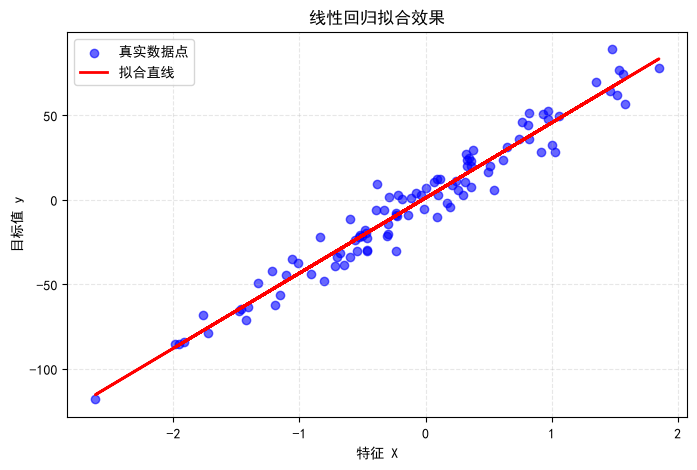

In [4]:
# ========== 1. 线性回归 ==========
# 生成数据集（1个特征，100个样本，带噪音）
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# 训练模型
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 打印参数
print(f"权重 (w): {model.coef_[0]:.2f}")
print(f"截距 (b): {model.intercept_:.2f}")

# 绘图
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='真实数据点', alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=2, label='拟合直线')
plt.xlabel('特征 X')
plt.ylabel('目标值 y')
plt.title('线性回归拟合效果')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 模型二：逻辑回归（Logistic Regression）
**目标**：在二维特征空间中画出一条决策边界，将两类样本分开。

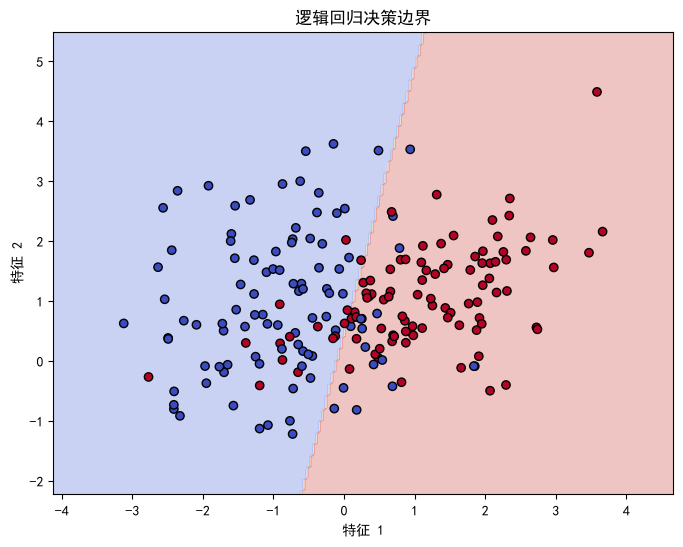

In [5]:
# ========== 2. 逻辑回归 ==========
# 生成二分类数据集（2个特征，方便可视化）
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# 训练模型
model = LogisticRegression()
model.fit(X, y)

# 绘制决策边界（在特征空间画网格）
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='coolwarm')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('逻辑回归决策边界')
plt.show()

## 模型三：决策树（Decision Tree）
**目标**：训练一棵决策树，并可视化其树状结构（深度限制为3层）。

决策树在训练集上的准确率: 97.33%


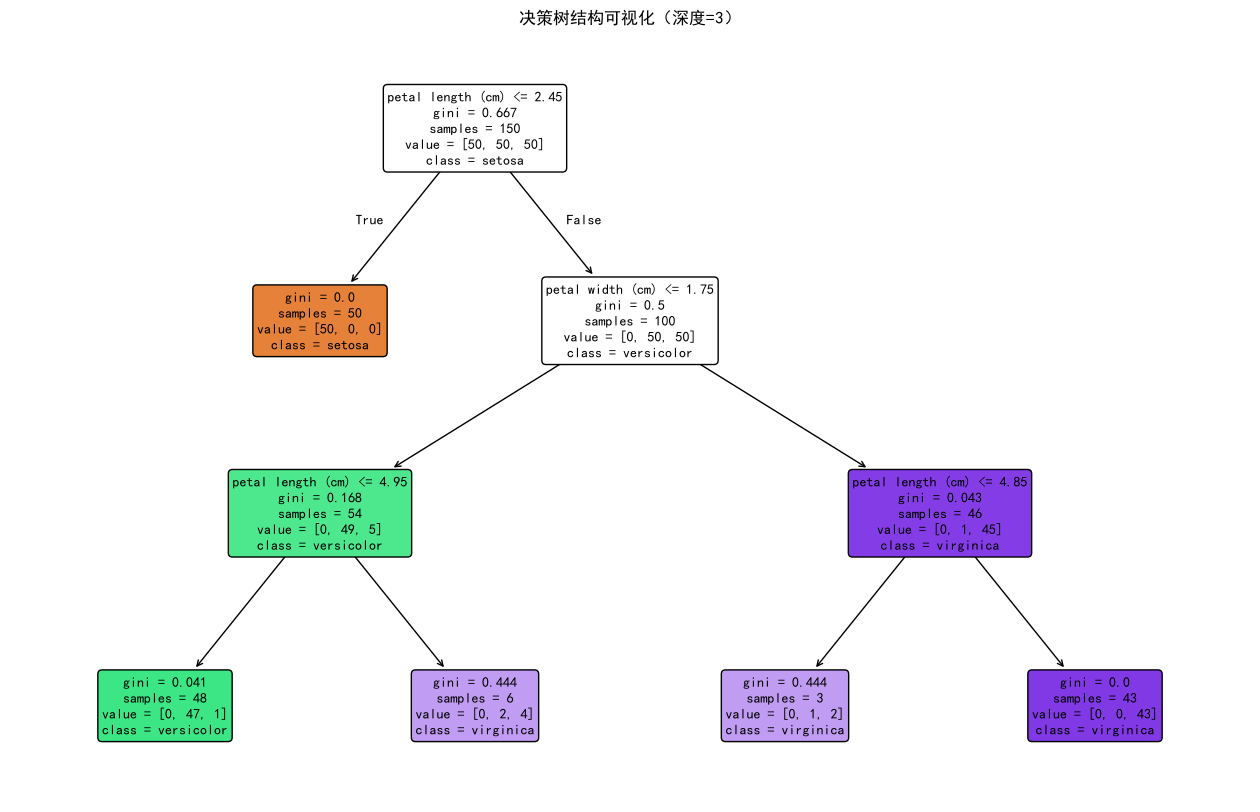

In [6]:
# ========== 3. 决策树 ==========
# 使用鸢尾花数据集（经典分类数据）
iris = load_iris()
X, y = iris.data, iris.target

# 训练决策树（限制深度为3，方便画图）
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

# 打印准确率
print(f"决策树在训练集上的准确率: {model.score(X, y):.2%}")

# 绘制树结构
plt.figure(figsize=(16, 10))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, 
          filled=True, rounded=True, fontsize=10)
plt.title('决策树结构可视化（深度=3）')
plt.show()

## 模型四：K-Means 聚类
**目标**：将数据自动划分为 3 个簇，并标出簇中心。

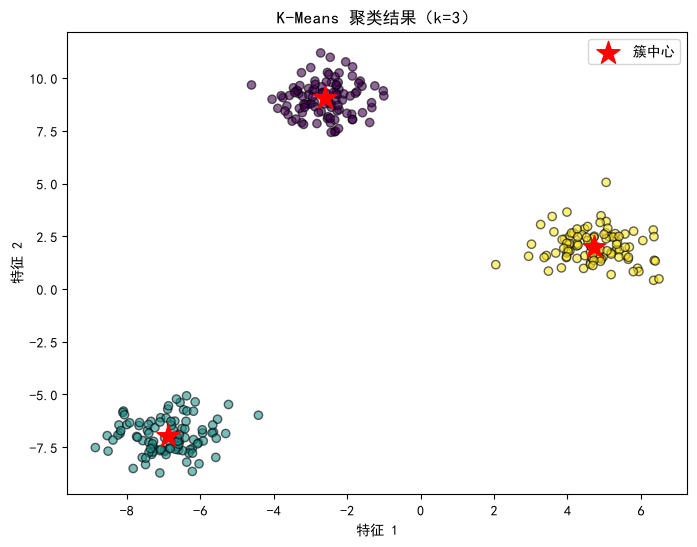

In [7]:
# ========== 4. K-Means 聚类 ==========
# 生成 3 簇数据
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# 训练 K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            marker='*', s=300, color='red', label='簇中心')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('K-Means 聚类结果（k=3）')
plt.legend()
plt.show()

## 模型五：主成分分析（PCA）
**目标**：将 4 维的鸢尾花数据降维到 2 维，并观察不同类别在二维平面上的分布。

PC1 解释方差比例: 72.96%
PC2 解释方差比例: 22.85%
累计解释方差: 95.81%


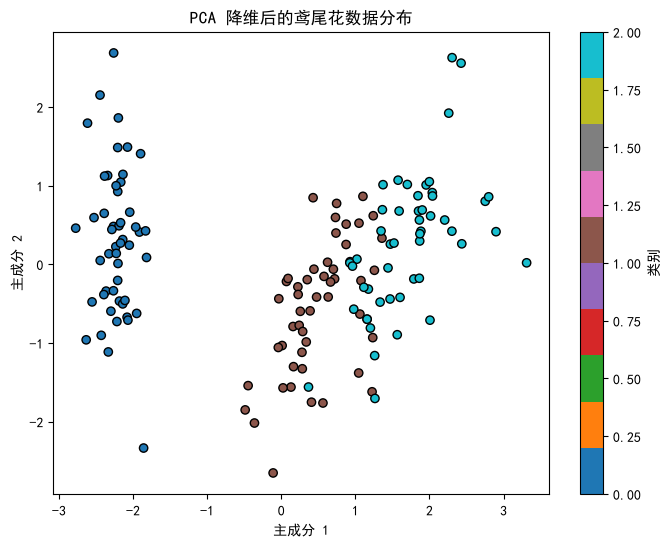

In [8]:
# ========== 5. PCA 降维 ==========
# 加载鸢尾花数据（4个特征）
iris = load_iris()
X, y = iris.data, iris.target

# 标准化（PCA对尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA降维到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 打印方差解释率
print(f"PC1 解释方差比例: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解释方差比例: {pca.explained_variance_ratio_[1]:.2%}")
print(f"累计解释方差: {sum(pca.explained_variance_ratio_):.2%}")

# 绘图
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', edgecolors='k')
plt.xlabel('主成分 1')
plt.ylabel('主成分 2')
plt.title('PCA 降维后的鸢尾花数据分布')
plt.colorbar(scatter, label='类别')
plt.show()

## 模型六：多层感知机（MLP）
**目标**：训练一个简单的神经网络（1个隐藏层），绘制训练过程中的损失下降曲线。

训练集准确率: 37.75%
验证集准确率: 31.00%


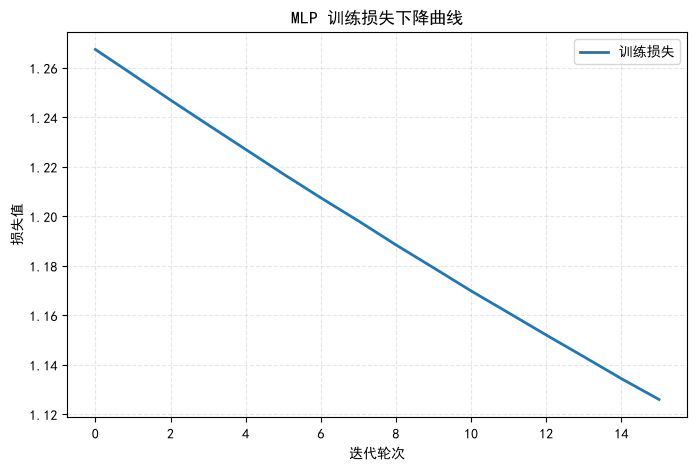

In [9]:
# ========== 6. MLP 神经网络 ==========
# 使用前面的二分类数据（2个特征，适合快速训练）
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# 划分训练集和验证集（展示早停概念）
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练 MLP（1个隐藏层，10个神经元）
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=300, random_state=42,
                    validation_fraction=0.1, early_stopping=True, n_iter_no_change=10)
mlp.fit(X_train, y_train)

# 打印准确率
print(f"训练集准确率: {mlp.score(X_train, y_train):.2%}")
print(f"验证集准确率: {mlp.score(X_val, y_val):.2%}")

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label='训练损失', linewidth=2)
plt.xlabel('迭代轮次')
plt.ylabel('损失值')
plt.title('MLP 训练损失下降曲线')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()